In [7]:
import numpy as nm
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import pandas as kt


In [9]:
def generate_data(n_samples=300, n_features=2, centers=4, random_state=42):
    
   
    X, y = make_blobs(n_samples=n_samples, n_features=n_features, 
                      centers=centers, random_state=random_state)
    
   
    noise_points = np.random.uniform(low=-10, high=10, size=(20, n_features))
    X = nm.vstack([X, noise_points])
    y = nm.append(y, [-1] * 20)
    
    
    X = StandardScaler().fit_transform(X)
    
    return X, y

In [11]:
def apply_dbscan(X, eps_values=[0.2, 0.4, 0.8], min_samples=5):
    results = []
    
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
       
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        
        num_noise = np.sum(labels == -1)
        
        
        cluster_sizes = {label: np.sum(labels == label) for label in set(labels) if label != -1}
        
      
        results.append((eps, num_clusters, num_noise, cluster_sizes))
        
        
        plt.figure(figsize=(8, 5))
        unique_labels = set(labels)
        colors = [plt.cm.jet(float(i) / max(unique_labels)) for i in unique_labels]
        
        for label, color in zip(unique_labels, colors):
            if label == -1:
                marker = 'x'  
            else:
                marker = 'o'
            
            plt.scatter(X[labels == label, 0], X[labels == label, 1], 
                        c=[color], label=f'Cluster {label}', marker=marker, edgecolors='k')
        
        plt.title(f'DBSCAN Clustering (eps={eps})')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.show()

In [15]:
results_df = kt.DataFrame(results, columns=['Epsilon', 'Number of Clusters', 'Noise Points', 'Cluster Sizes'])
    print(results_df)

IndentationError: unexpected indent (2214074753.py, line 2)

C:\Users\karun\AppData\Local\Temp\ipykernel_4420\3911533409.py:31: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[labels == label, 0], X[labels == label, 1],


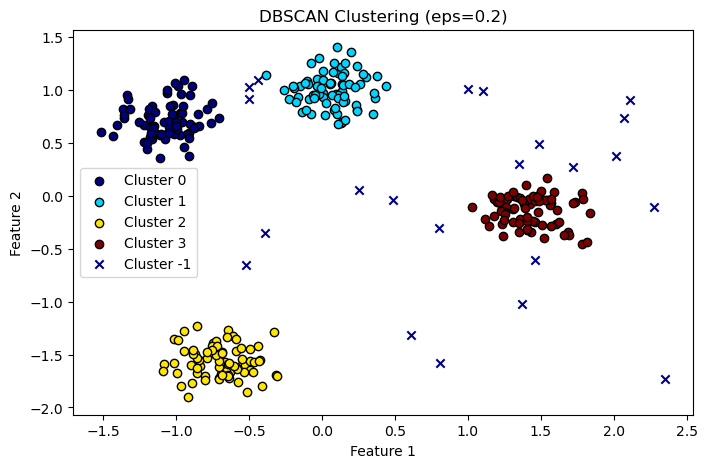

C:\Users\karun\AppData\Local\Temp\ipykernel_4420\3911533409.py:31: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[labels == label, 0], X[labels == label, 1],


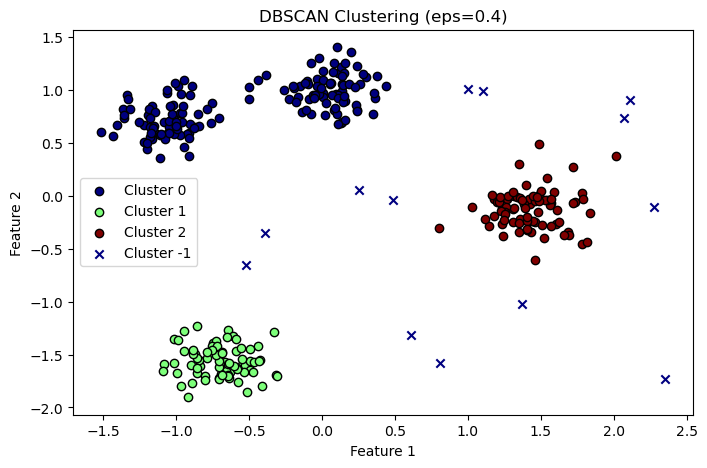

C:\Users\karun\AppData\Local\Temp\ipykernel_4420\3911533409.py:31: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[labels == label, 0], X[labels == label, 1],


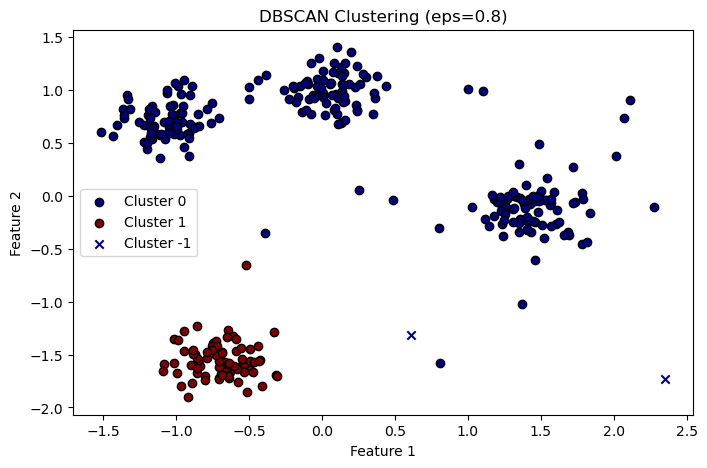

In [13]:
def main():
    
    X, true_labels = generate_data(n_samples=300, centers=4)
    
  
    apply_dbscan(X)
    

if __name__ == "__main__":
    main()


In [ ]:
For  0.2 the clustering is too tight and there are many small fragmented clusters with a large number of noise points.

For 0.4 the clustering is balanced and it creates a moderate number of meaningful clusters while maintaining some noise points.

For 0.8 the clustering is too loose, combining most of the points in a few large clusters with very few noise points, potentially clustering unrelated data points together.

Overall, 0.4 provides the best balance between useful clusters and noise elimination